# **House Price Prediction – End Sem Project (ML + Regression + Feature Engineering)**




# **Step 1: Import Libraries**

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")


# **Step 2: Load the Dataset**

In [8]:
# Load the training dataset
df = pd.read_csv('/content/train.csv')
df.head()



,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# **Step 3: Exploratory Data Analysis (EDA)**

**Basic Info**

In [9]:
print("Shape:", df.shape)
print("Missing values:\n", df.isnull().sum().sort_values(ascending=False).head(10))
df.describe()


Shape: (1460, 81)
Missing values:
 PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
dtype: int64


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


**SalePrice Distribution**

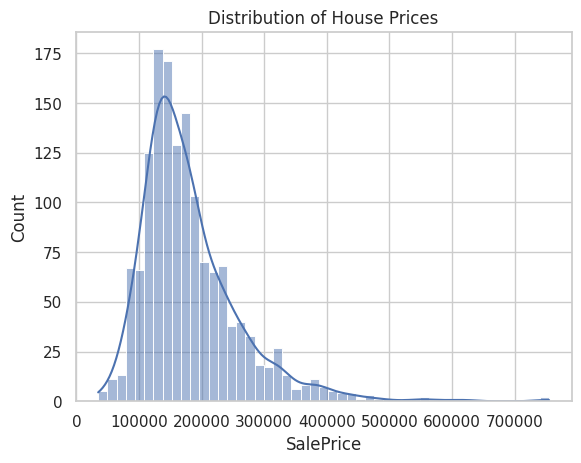

In [10]:
sns.histplot(df['SalePrice'], kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.show()

**Correlation with SalePrice**

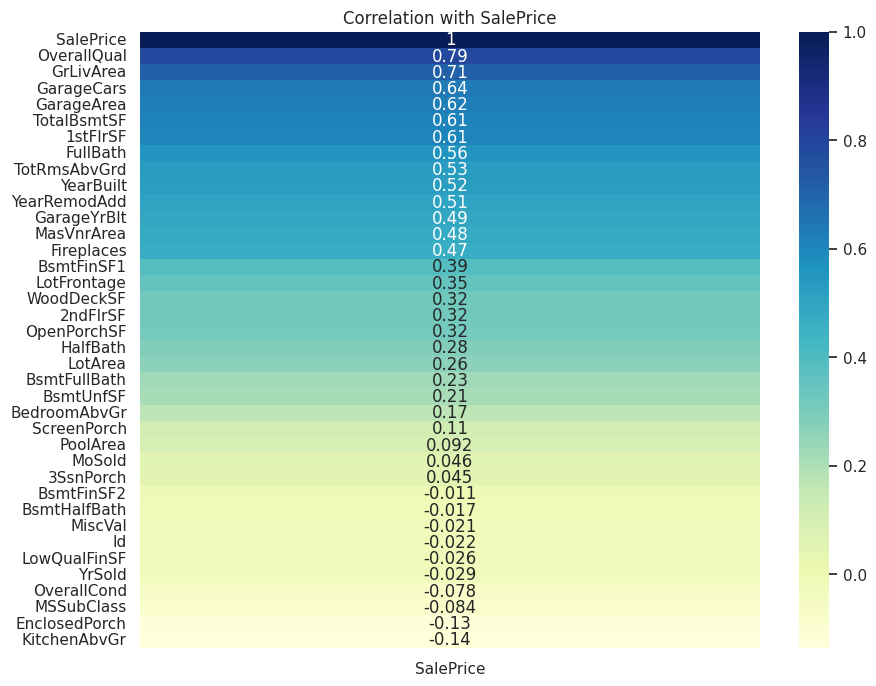

In [11]:
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr[['SalePrice']].sort_values(by='SalePrice', ascending=False), annot=True, cmap="YlGnBu")
plt.title("Correlation with SalePrice")
plt.show()


# **Step 4: Data Cleaning and Preprocessing**

**Remove columns with too many null values**

In [12]:
df = df.drop(['Alley', 'PoolQC', 'Fence', 'MiscFeature', 'FireplaceQu'], axis=1)


**Fill missing values**

In [13]:
# Fill numeric columns with median
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical columns with mode
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])


**Encode categorical columns**

In [14]:
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])


# **Step 5: Feature & Target Separation**

In [15]:
X = df.drop(['Id', 'SalePrice'], axis=1)
y = df['SalePrice']


# **Step 6: Train-Test Split**

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# **Step 7: Model Training & Evaluation**

**Linear Regression**

In [17]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Linear Regression R² Score:", r2_score(y_test, y_pred_lr))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))


Linear Regression R² Score: 0.8455080985714246
Linear Regression RMSE: 34423.876602233104


**Ridge Regression**

In [18]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

print("Ridge Regression R² Score:", r2_score(y_test, y_pred_ridge))


Ridge Regression R² Score: 0.8454396102494625


**Lasso Regression**

In [19]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

print("Lasso Regression R² Score:", r2_score(y_test, y_pred_lasso))


Lasso Regression R² Score: 0.8455085182015545


# **Step 8: Visualization – Actual vs Predicted (Linear Regression)**

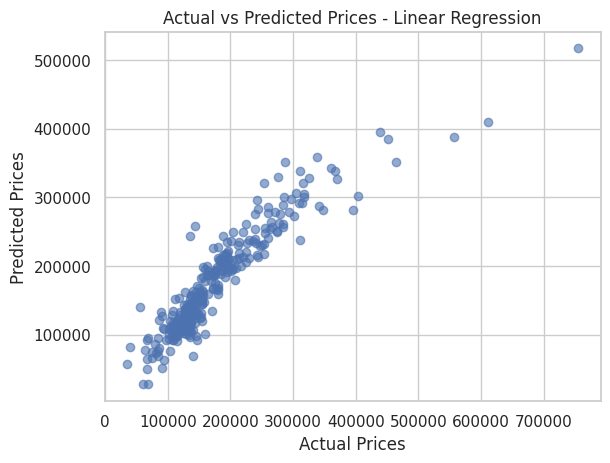

In [23]:
plt.scatter(y_test, y_pred_lr, alpha=0.6)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices - Linear Regression")
plt.show()

# **Step 9: Predict House Price**

In [22]:
# Step 1: Define input fields
def predict_house_price():
    print("Enter the following details:")

    overall_qual = int(input("Overall Quality (1-10): "))
    gr_liv_area = float(input("Above Grade Living Area (sq ft): "))
    garage_cars = int(input("Garage Cars: "))
    total_bsmt_sf = float(input("Total Basement Area (sq ft): "))
    full_bath = int(input("Number of Full Bathrooms: "))
    year_built = int(input("Year Built: "))

    # Step 2: Create a DataFrame for the input
    input_data = pd.DataFrame({
        'OverallQual': [overall_qual],
        'GrLivArea': [gr_liv_area],
        'GarageCars': [garage_cars],
        'TotalBsmtSF': [total_bsmt_sf],
        'FullBath': [full_bath],
        'YearBuilt': [year_built]
    })

    # Step 3: Train model again on these selected features
    selected_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']
    X_simple = df[selected_features]
    y_simple = df['SalePrice']

    model = LinearRegression()
    model.fit(X_simple, y_simple)

    # Step 4: Predict
    predicted_price = model.predict(input_data)[0]
    print(f"\n✅ Predicted House Price: ${predicted_price:,.2f}")

# Call the function
predict_house_price()


Enter the following details:
Overall Quality (1-10): 5
Above Grade Living Area (sq ft): 45
Garage Cars: 2
Total Basement Area (sq ft): 80
Number of Full Bathrooms: 4
Year Built: 2020

✅ Predicted House Price: $56,732.94
